In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cmocean
import phate
import scprep
import meld
import sklearn
import tempfile
import os
import scanpy as sc
import scipy
from matplotlib.colors import LinearSegmentedColormap


# making sure plots & clusters are reproducible
np.random.seed(42)

In [2]:
adata = sc.read('/rds/project/rds-SDzz0CATGms/users/ti283/Preleukemia/analysis/Jak2/Integrated_wo_regress_all_projected_LK_only.h5ad')

In [3]:
adata.obs['replicates'] = adata.obs['library']
adata.obs['replicates'] = adata.obs['replicates'].astype('str')

In [4]:
Homo_rep1 = ['SLX11516_SIGAB2']
Homo_rep2 = ['SLX11525_SIGAB3']
Homo_rep3 = ['SLX12969_SIGAB8']

WT_rep1 = ['SLX11516_SIGAC2']
WT_rep2 = ['SLX11525_SIGAH2']
WT_rep3 = ['SLX12969_SIGAA8']

Het_rep1 = ['SLX11516_SIGAD2']
Het_rep2 = ['SLX11525_SIGAA3']
Het_rep3 = ['SLX12969_SIGAC8']

In [5]:
Homo_WT = ['SLX11516_SIGAB2','SLX11525_SIGAB3','SLX12969_SIGAB8',
          'SLX11516_SIGAC2','SLX11525_SIGAH2','SLX12969_SIGAA8']

Het_WT = ['SLX11516_SIGAD2','SLX11525_SIGAA3','SLX12969_SIGAC8',
          'SLX11516_SIGAC2','SLX11525_SIGAH2','SLX12969_SIGAA8']

In [6]:
adata = adata[adata.obs['library'].isin(Homo_WT),:].copy()

In [7]:
adata.obs['replicates'][adata.obs['library'].isin(Homo_rep1)] = 'Jak2_Homo_rep1'
adata.obs['replicates'][adata.obs['library'].isin(Homo_rep2)] = 'Jak2_Homo_rep2'
adata.obs['replicates'][adata.obs['library'].isin(Homo_rep3)] = 'Jak2_Homo_rep3'

adata.obs['replicates'][adata.obs['library'].isin(WT_rep1)] = 'Jak2_WT_rep1'
adata.obs['replicates'][adata.obs['library'].isin(WT_rep2)] = 'Jak2_WT_rep2'
adata.obs['replicates'][adata.obs['library'].isin(WT_rep3)] = 'Jak2_WT_rep3'

<ipython-input-7-c71cf41b44f1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['replicates'][adata.obs['library'].isin(Homo_rep1)] = 'Jak2_Homo_rep1'
<ipython-input-7-c71cf41b44f1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['replicates'][adata.obs['library'].isin(Homo_rep2)] = 'Jak2_Homo_rep2'
<ipython-input-7-c71cf41b44f1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['replicates'][adata.obs['li

In [8]:
adata.obs['replicates'] = adata.obs['replicates'].astype('category')

In [9]:
data = adata.to_df()
metadata = adata.obs

In [10]:
np.unique(adata.obs['library'])

array(['SLX11516_SIGAB2', 'SLX11516_SIGAC2', 'SLX11525_SIGAB3',
       'SLX11525_SIGAH2', 'SLX12969_SIGAA8', 'SLX12969_SIGAB8'],
      dtype=object)

In [11]:
sample_cmap = {
    'Jak2_Homo_rep1': '#fb6a4a',
    'Jak2_Homo_rep2': '#de2d26',
    'Jak2_Homo_rep3': '#a50f15',
    'Jak2_WT_rep1': '#6baed6',
    'Jak2_WT_rep2': '#3182bd',
    'Jak2_WT_rep3': '#08519c'
}

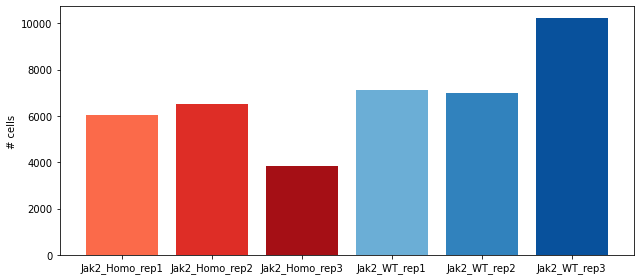

In [12]:
fig, ax = plt.subplots(1,figsize=(9,4))

groups, counts = np.unique(metadata['replicates'], return_counts=True)
for i, c in enumerate(counts):
    ax.bar(i, c, color=sample_cmap[groups[i]])
    
ax.set_xticks(np.arange(i+1))
ax.set_xticklabels(groups)
ax.set_ylabel('# cells')

fig.tight_layout()

In [13]:
data_pca = adata.obsm['X_pca']

In [14]:
data_phate = adata.obsm['X_umap']

<AxesSubplot:xlabel='UMAP1', ylabel='UMAP2'>

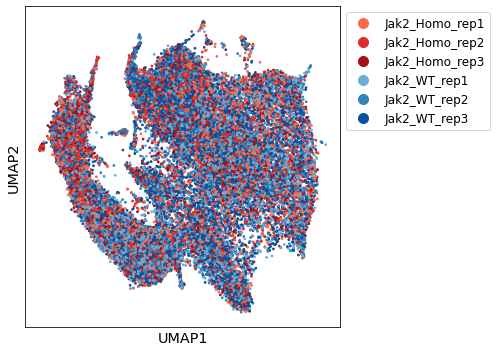

In [15]:
scprep.plot.scatter2d(data_phate, c=metadata['replicates'], cmap=sample_cmap, 
                      legend_anchor=(1,1), figsize=(7,5), s=3, label_prefix='UMAP', ticks=False)

<AxesSubplot:xlabel='UMAP1', ylabel='UMAP2'>

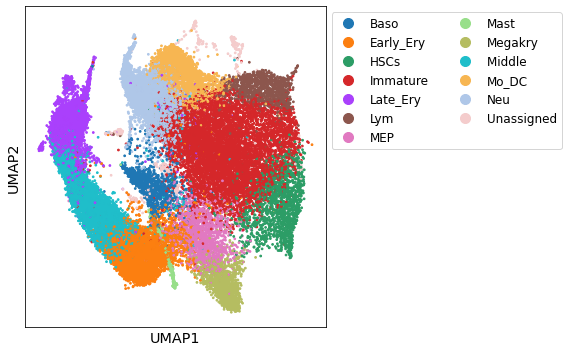

In [16]:
scprep.plot.scatter2d(data_phate, c=metadata['predicted.id'], cmap=adata.uns['predicted.id_colors'], 
                      legend_anchor=(1,1), figsize=(8,5), s=3, label_prefix='UMAP', ticks=False)

In [17]:
metadata['genotype_name'] = np.where(metadata['replicates'].str.startswith("Jak2_Homo"), "Homo", "WT")
metadata['genotype'] = np.where(metadata['genotype_name'] == "Homo", 1, 0)
metadata['replicate'] = metadata['replicates'].str[-4:-1] + metadata['replicates'].str[-1]

In [18]:
# beta is the amount of smoothing to do for density estimation
# knn is the number of neighbors used to set the kernel bandwidth
meld_op = meld.MELD(beta=15, knn=8)
sample_densities = meld_op.fit_transform(data_pca, sample_labels=metadata['replicates'])

Building graph on 40747 samples and 50 features.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 59.91 seconds.
  Calculating affinities...
  Calculated affinities in 2.53 seconds.
Calculated graph and diffusion operator in 63.27 seconds.


# Compare pairwise between embryo pools!

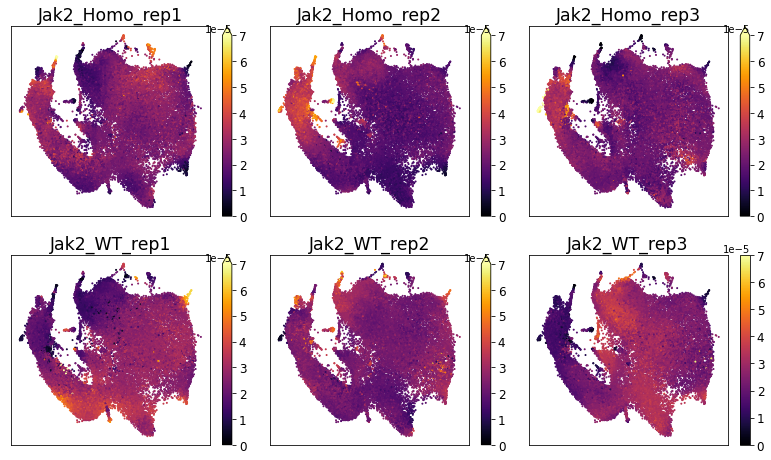

In [19]:
fig, axes = plt.subplots(2,3, figsize=(11,6.5))

for i, ax in enumerate(axes.flatten()):
    density = sample_densities.iloc[:,i]
    scprep.plot.scatter2d(data_phate, c=density,
                          title=density.name,
                          vmin=0, vmax=7e-5,
                          ticks=False, ax=ax)
    
fig.tight_layout()

In [20]:
sample_densities

,Jak2_Homo_rep1,Jak2_Homo_rep2,Jak2_Homo_rep3,Jak2_WT_rep1,Jak2_WT_rep2,Jak2_WT_rep3
0,0.000022,0.000021,0.000023,0.000031,0.000033,0.000019
1,0.000031,0.000034,0.000036,0.000020,0.000023,0.000015
2,0.000024,0.000013,0.000025,0.000027,0.000019,0.000034
3,0.000023,0.000029,0.000027,0.000027,0.000022,0.000021
4,0.000018,0.000016,0.000020,0.000039,0.000024,0.000026
...,...,...,...,...,...,...
40742,0.000029,0.000037,0.000031,0.000020,0.000025,0.000015
40743,0.000032,0.000034,0.000030,0.000024,0.000024,0.000014
40744,0.000027,0.000019,0.000026,0.000024,0.000034,0.000020
40745,0.000020,0.000026,0.000018,0.000021,0.000027,0.000030


In [21]:
pval=np.array([])

for i in sample_densities.index:
    mut_i = sample_densities.loc[i][0:3]
    wt_i = sample_densities.loc[i][3:6]
    #pval_i = scipy.stats.ttest_ind(mut_i,wt_i)[1] # set equal_var = False for Welch's t-test. Default is Student's t-test.
    pval_i = scipy.stats.ttest_rel(mut_i,wt_i)[1] # paired t-test
    pval = np.append(pval,pval_i)

print(pval)

[0.40351928 0.04760118 0.08957517 ... 0.80193247 0.2840519  0.02746127]


In [22]:
# This is a helper function to apply L1 normalization across the densities for each replicate
def replicate_normalize_densities(sample_densities, replicate):
    # Get the unique replicates
    replicates = np.unique(replicate)[0:3] # removing "WT"
    sample_likelihoods = sample_densities.copy()
    for rep in replicates:
        # Select the columns of `sample_densities` for that replicate
        #curr_cols = sample_densities.columns[[col.endswith(rep) for col in sample_densities.columns]]
        curr_densities_1 = sample_densities[[rep,'Jak2_WT_rep1']]
        curr_densities_2 = sample_densities[[rep,'Jak2_WT_rep2']]
        curr_densities_3 = sample_densities[[rep,'Jak2_WT_rep3']]
        # Apply L1 normalization
        sample_likelihoods[str(rep)+'_comp1'] = sklearn.preprocessing.normalize(curr_densities_1, norm='l1')[:,0]
        sample_likelihoods[str(rep)+'_comp2'] = sklearn.preprocessing.normalize(curr_densities_2, norm='l1')[:,0]
        sample_likelihoods[str(rep)+'_comp3'] = sklearn.preprocessing.normalize(curr_densities_3, norm='l1')[:,0]
    return sample_likelihoods

In [23]:
sample_likelihoods = replicate_normalize_densities(sample_densities, metadata['replicates'])

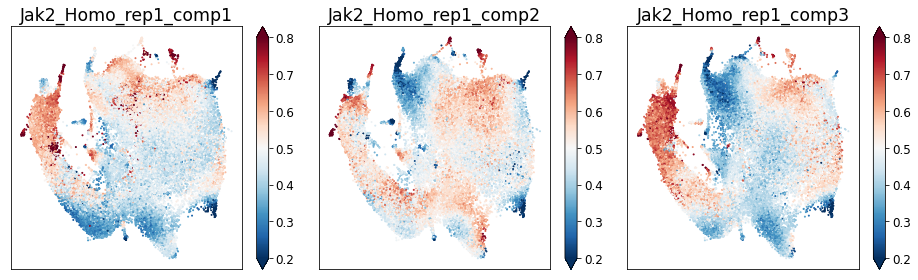

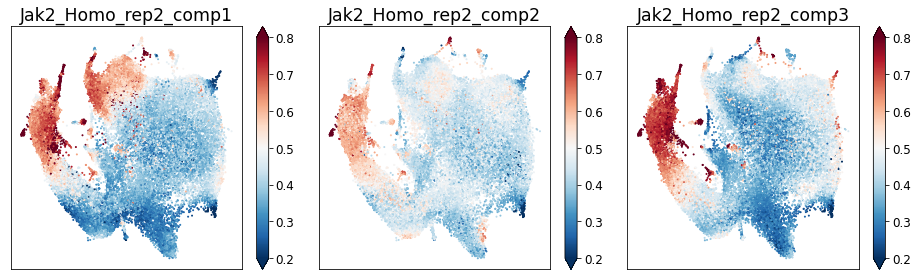

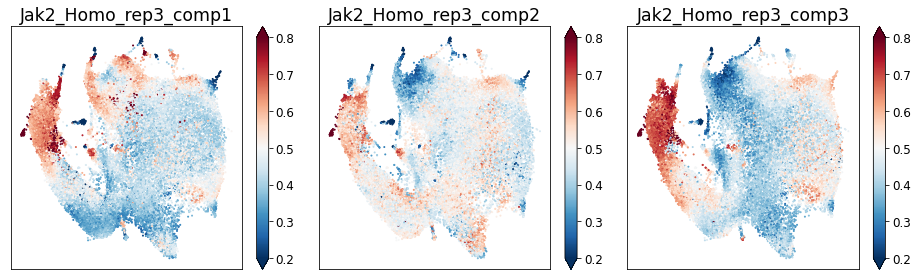

In [24]:
########################################################
# Comp1 (Homo_rep1 vs WT reps)
fig, axes = plt.subplots(1,3, figsize=(13,4))

experimental_samples = ['Jak2_Homo_rep1_comp1', 'Jak2_Homo_rep1_comp2', 'Jak2_Homo_rep1_comp3']

for curr_sample, ax in zip(experimental_samples, axes):
    scprep.plot.scatter2d(data_phate, c=sample_likelihoods[curr_sample],
                          cmap='RdBu_r',
                          vmin=0.2, vmax=.8,
                          title=curr_sample, ticks=False, ax=ax)

fig.tight_layout()

########################################################
# Comp2 (Homo_rep2 vs WT reps)
fig, axes = plt.subplots(1,3, figsize=(13,4))

experimental_samples = ['Jak2_Homo_rep2_comp1', 'Jak2_Homo_rep2_comp2', 'Jak2_Homo_rep2_comp3']

for curr_sample, ax in zip(experimental_samples, axes):
    scprep.plot.scatter2d(data_phate, c=sample_likelihoods[curr_sample],
                          cmap='RdBu_r',
                          vmin=0.2, vmax=.8,
                          title=curr_sample, ticks=False, ax=ax)

fig.tight_layout()

########################################################
# Comp3 (Homo_rep3 vs WT reps)
fig, axes = plt.subplots(1,3, figsize=(13,4))

experimental_samples = ['Jak2_Homo_rep3_comp1', 'Jak2_Homo_rep3_comp2', 'Jak2_Homo_rep3_comp3']


for curr_sample, ax in zip(experimental_samples, axes):
    scprep.plot.scatter2d(data_phate, c=sample_likelihoods[curr_sample],
                          cmap='RdBu_r',
                          vmin=0.2, vmax=.8,
                          title=curr_sample, ticks=False, ax=ax)

fig.tight_layout()


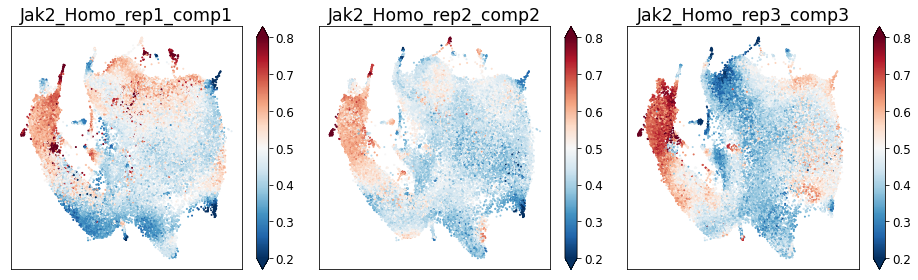

In [25]:
########################################################
# Only pairwise comp
fig, axes = plt.subplots(1,3, figsize=(13,4))

experimental_samples = ['Jak2_Homo_rep1_comp1', 'Jak2_Homo_rep2_comp2', 'Jak2_Homo_rep3_comp3']


for curr_sample, ax in zip(experimental_samples, axes):
    scprep.plot.scatter2d(data_phate, c=sample_likelihoods[curr_sample],
                          cmap='RdBu_r',
                          vmin=0.2, vmax=.8,
                          title=curr_sample, ticks=False, ax=ax)

fig.tight_layout()



In [26]:
#experimental_samples = ['Jak2_Homo_rep1_comp1', 'Jak2_Homo_rep1_comp2', 'Jak2_Homo_rep1_comp3',
#                       'Jak2_Homo_rep2_comp1', 'Jak2_Homo_rep2_comp2', 'Jak2_Homo_rep2_comp3',
#                       'Jak2_Homo_rep3_comp1', 'Jak2_Homo_rep3_comp2', 'Jak2_Homo_rep3_comp3']

experimental_samples = ['Jak2_Homo_rep1_comp1', 'Jak2_Homo_rep2_comp2', 'Jak2_Homo_rep3_comp3']

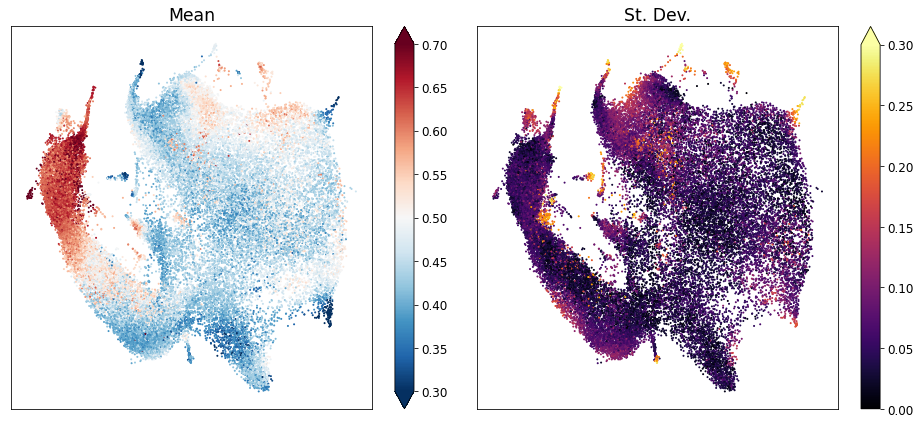

In [27]:
fig, axes = plt.subplots(1,2, figsize=(13.1,6))
scprep.plot.scatter2d(data_phate, c=sample_likelihoods[experimental_samples].mean(axis=1), 
#                      cmap=meld.get_meld_cmap(), vmin=0, vmax=1,
                      cmap='RdBu_r', vmin=0.3, vmax=0.7,
                      title='Mean', ticks=False, ax=axes[0])
scprep.plot.scatter2d(data_phate, c=sample_likelihoods[experimental_samples].std(axis=1),
                      vmin=0,vmax=0.3,cmap='inferno', title='St. Dev.', ticks=False, ax=axes[1])

fig.tight_layout()

<AxesSubplot:ylabel='Number of cells'>

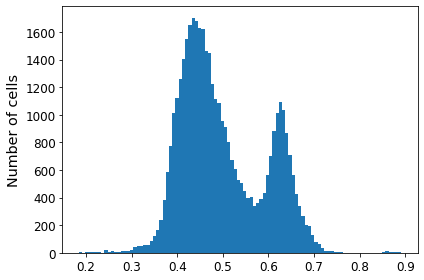

In [28]:
scprep.plot.histogram(sample_likelihoods[experimental_samples].mean(axis=1))

<AxesSubplot:ylabel='Number of cells'>

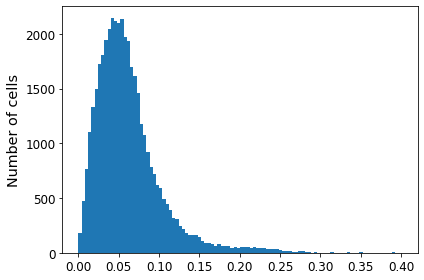

In [29]:
scprep.plot.histogram(sample_likelihoods[experimental_samples].std(axis=1))

In [30]:
#sample_likelihoods['pvalue'] = Ttest_res.pvalue
sample_likelihoods['pvalue'] = pval

In [31]:
def p_adjust_bh(p):
    """Benjamini-Hochberg p-value correction for multiple hypothesis testing."""
    p = np.asfarray(p)
    by_descend = p.argsort()[::-1]
    by_orig = by_descend.argsort()
    steps = float(len(p)) / np.arange(len(p), 0, -1)
    q = np.minimum(1, np.minimum.accumulate(steps * p[by_descend]))
    return q[by_orig]

In [32]:
#sample_likelihoods['p_adj'] = p_adjust_bh(Ttest_res.pvalue)
sample_likelihoods['p_adj'] = p_adjust_bh(pval)

<AxesSubplot:title={'center':'Mean'}>

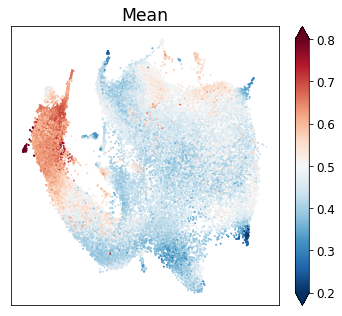

In [33]:
scprep.plot.scatter2d(data_phate, c=sample_likelihoods[experimental_samples].mean(axis=1), 
#                      cmap=meld.get_meld_cmap(), vmin=0, vmax=1,
                      cmap='RdBu_r', vmin=0.2, vmax=0.8,
                      title='Mean', ticks=False,figsize=(5,4.5))

In [34]:
idx_p = sample_likelihoods['pvalue'].argsort()
idx_q = sample_likelihoods['p_adj'].argsort()

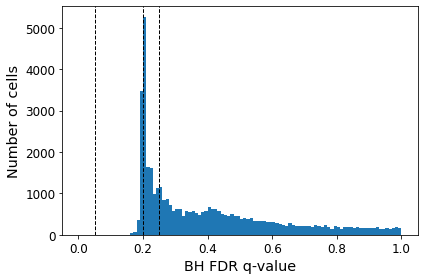

In [35]:
scprep.plot.histogram(sample_likelihoods['p_adj'],xlabel='BH FDR q-value')
plt.axvline(0.05, color='k', linestyle='dashed', linewidth=1)
plt.axvline(0.2, color='k', linestyle='dashed', linewidth=1)
plt.axvline(0.25, color='k', linestyle='dashed', linewidth=1)

In [36]:
print(np.unique(np.char.add(np.array(sample_likelihoods['p_adj']<0.05).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))))
print(np.unique(np.char.add(np.array(sample_likelihoods['p_adj']<0.1).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))))
print(np.unique(np.char.add(np.array(sample_likelihoods['p_adj']<0.2).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))))

['FalseFalse' 'FalseTrue' 'TrueTrue']
['FalseFalse' 'FalseTrue' 'TrueTrue']
['FalseFalse' 'FalseTrue' 'TrueFalse' 'TrueTrue']


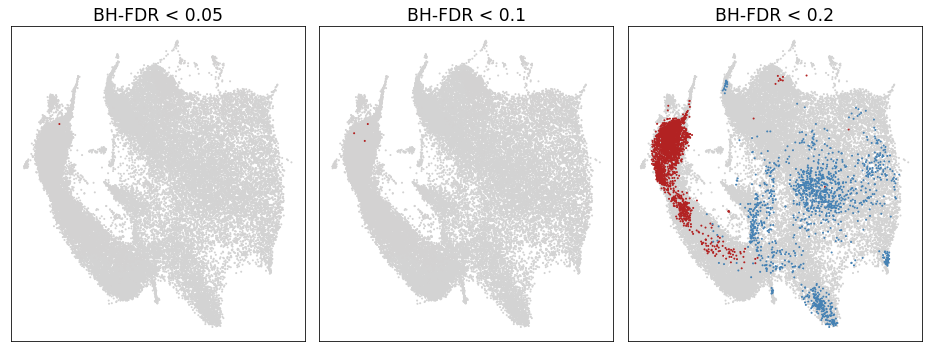

In [37]:
fig, axes = plt.subplots(1,3, figsize=(13,5))

#scprep.plot.scatter2d(data_phate[idx_p[::-1]],
#                      c=np.char.add(np.array(sample_likelihoods['pvalue']<0.05).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))[idx_p[::-1]], 
#                      cmap=LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey','lightgrey', 'steelblue','firebrick']),
#                      title='Pval < 0.05', ticks=False,shuffle=False,legend=False, ax=axes[0])

scprep.plot.scatter2d(data_phate[idx_q[::-1]],
                      c=np.char.add(np.array(sample_likelihoods['p_adj']<0.05).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))[idx_q[::-1]], 
                      cmap=LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey','lightgrey','firebrick']),
                      title='BH-FDR < 0.05', ticks=False,shuffle=False,legend=False, ax=axes[0])

scprep.plot.scatter2d(data_phate[idx_q[::-1]],
                      c=np.char.add(np.array(sample_likelihoods['p_adj']<0.1).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))[idx_q[::-1]], 
                      cmap=LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey','lightgrey','firebrick']),
                      title='BH-FDR < 0.1', ticks=False,shuffle=False,legend=False, ax=axes[1])

scprep.plot.scatter2d(data_phate[idx_q[::-1]],
                      c=np.char.add(np.array(sample_likelihoods['p_adj']<0.2).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))[idx_q[::-1]], 
                      cmap=LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey','lightgrey', 'steelblue','firebrick']),
                      title='BH-FDR < 0.2', ticks=False,shuffle=False,legend=False, ax=axes[2])


fig.tight_layout()




<AxesSubplot:title={'center':'BH-FDR < 0.25'}>

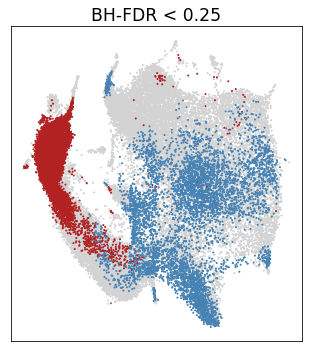

In [42]:
#Sets figure size
from matplotlib import rcParams
rcParams['figure.figsize'] = (4.4, 5)

scprep.plot.scatter2d(data_phate[idx_q[::-1]],
                      c=np.char.add(np.array(sample_likelihoods['p_adj']<0.25).astype('str'),np.array(sample_likelihoods[experimental_samples].mean(axis=1)>0.5).astype('str'))[idx_q[::-1]], 
                      cmap=LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey','lightgrey', 'steelblue','firebrick']),
                      title='BH-FDR < 0.25', ticks=False,shuffle=False,legend=False)